# 03. Optimization and parametric analysis

The first two notebooks established the game and the agents. This one
runs the experiments: how much does deeper search help, how does
pre-allocation count change the outcome distribution, and can we tune
the heuristic weights to do better than the hand-picked defaults.

Every experiment caches its raw game data into `cache/results/` as a
pickle, so re-running the notebook is cheap once the slow runs are
done. Delete `cache/` to force a full recompute.


In [1]:
# Standard imports plus the executor we use to spread games across CPU cores.
import itertools
import os
import pickle
import random
import sys
import time

import pandas as pd

# Notebooks live in ./notebooks/, so add the project root to sys.path
# before importing our local modules.
_here = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _here not in sys.path:
    sys.path.insert(0, _here)
import settings, tictactoe66
import experiments
from experiments import (
    run_or_load, make_spec, make_spec as _spec, make_balanced_jobs,
    run_games as _exp_run_games, games_to_df, wilson_ci,
)

game = tictactoe66.TicTacToe66()

# Allocate the worker pool once (Windows spawn is slow) and pre-warm so
# the numba JIT compile happens in parallel up front instead of stalling
# the first real batch.
POOL, MAX_WORKERS = experiments.make_pool()

def run_games(jobs):
    """Notebook-local thin wrapper that injects the shared POOL."""
    return _exp_run_games(jobs, POOL, MAX_WORKERS)

print("cache dir:", settings.CACHE_DIR)
print("workers :", MAX_WORKERS)

_warm_seconds = experiments.prewarm_pool(POOL, MAX_WORKERS)
print(f"prewarmed {MAX_WORKERS} workers in {_warm_seconds:.1f}s")


cache dir: C:\Git\AI801Project\cache
workers : 32


prewarmed 32 workers in 0.9s


## Helpers

Each experiment below boils down to "play a lot of games and tabulate the results".
We feed every game to a single shared `ProcessPoolExecutor` so all CPU cores stay
busy and we only pay the (slow) Windows worker-spawn cost once.

Sides are alternated game-by-game (`a_is_X = i % 2 == 0`) so the X-first advantage
cancels out, and each game gets its own deterministic seed so re-runs are reproducible
regardless of the order in which workers finish.

In [2]:
# All experiment helpers (run_or_load, make_spec, make_balanced_jobs,
# run_games, games_to_df, wilson_ci) now live in ../experiments.py so
# notebooks 03, 04, and 05 share a single implementation. The local
# ``run_games`` defined in the cell above injects this notebook's POOL.


## Sample-size choice

Every win rate in this notebook is a point estimate from a finite number of
games, so it's worth working out up front how many games we actually need.
The half-width of the Wilson 95% interval at p=0.5 is roughly
`1.96 * sqrt(0.25 / N)`, which shrinks as `1/sqrt(N)`. In other words,
tighter intervals cost quadratically.

The table below answers the more useful question: how many games does it
take to reliably detect an absolute win-rate gain of `delta` over a 50%
null at alpha=0.05 and power=0.80? That sets the per-cell budget.

The tuning step in expC is a cheap screen at `TUNING_DEPTH=2` with
`N_TUNING_GAMES=80` per candidate (Wilson half-width ~0.11). Its job is
just to surface a few promising weight vectors. The validation cell that
follows re-plays the top-K candidates at `DEFAULT_DEPTH=3` with fresh
seeds and a multiple-comparison-aware threshold, and that's where any
"tuned weights beat the defaults" claim has to actually clear.


In [3]:
from math import ceil, sqrt

# Standard two-proportion sample-size formula for a single proportion
# tested against the null p0=0.5. delta is the absolute effect we want
# to be able to detect.
z_alpha = 1.96
z_beta  = 0.8416
p0      = 0.5

rows = []
for delta in [0.05, 0.075, 0.10, 0.15, 0.20]:
    p1 = p0 + delta
    n_needed = ((z_alpha * sqrt(p0 * (1 - p0))
                 + z_beta  * sqrt(p1 * (1 - p1))) / delta) ** 2
    n_needed = int(ceil(n_needed))
    halfwidth = 1.96 * sqrt(p0 * (1 - p0) / n_needed)
    rows.append(dict(effect=f"+{delta:.0%}",
                     n_needed=n_needed,
                     ci_halfwidth_at_p_half=round(halfwidth, 3)))
power_df = pd.DataFrame(rows)
print("Games needed to detect a gain vs 50% null "
      "(alpha=0.05, power=0.80):")
print(power_df.to_string(index=False))
print()
print(f"In this notebook: N_GAMES_PER_CONFIG = {settings.N_GAMES_PER_CONFIG} "
      f"resolves ~+15%; N_TUNING_GAMES = {settings.N_TUNING_GAMES} "
      f"resolves ~+10%.")

Games needed to detect a gain vs 50% null (alpha=0.05, power=0.80):
effect  n_needed  ci_halfwidth_at_p_half
   +5%       783                   0.035
   +8%       347                   0.053
  +10%       194                   0.070
  +15%        85                   0.106
  +20%        47                   0.143

In this notebook: N_GAMES_PER_CONFIG = 80 resolves ~+15%; N_TUNING_GAMES = 80 resolves ~+10%.


## Experiment A: depth sweep, AB(d) vs AB(d=1)

Random opponents are too weak to discriminate between depths (even d=1
with our heuristic beats them every time), so the baseline here is
AB(d=1) instead. Deeper search should win more games and, since it sees
mating sequences earlier, also finish them in fewer plies.


In [4]:
def expA():
    baseline = _spec("ab", depth=1)
    jobs = []
    for d in settings.DEPTH_SWEEP:
        deep = _spec("ab", depth=d)
        jobs.extend(make_balanced_jobs(
            deep, baseline, n_prealloc=2,
            n_games=settings.N_GAMES_PER_CONFIG,
            seed=100 + d, tag=d))
    df = games_to_df(run_games(jobs), label_a="deep", label_b="d1")
    return df.rename(columns={"tag": "depth"})

dfA = run_or_load("expA_depth_vs_d1", expA)
summary_A = (dfA.groupby("depth")
                .agg(win_deep =("winner_label", lambda s: (s == "deep").mean()),
                     loss_deep=("winner_label", lambda s: (s == "d1").mean()),
                     draw     =("winner_label", lambda s: (s == "draw").mean()),
                     mean_plies  =("plies",   "mean"),
                     mean_seconds=("seconds", "mean")))
summary_A

[run]   computing expA_depth_vs_d1.pkl ...


        done in 4.4s


,win_deep,loss_deep,draw,mean_plies,mean_seconds
depth,,,,,
1,0.5125,0.3875,0.1000,12.3875,0.029186
2,0.4500,0.5250,0.0250,10.7875,0.123654
3,0.5875,0.3500,0.0625,13.2750,1.150847


### Visualizing the depth sweep

Two views of the same data: the W/L/D split as a stacked bar, and the
cost of search (mean seconds per game) on a log axis. The log-scale
curve is the headline result for the report. Alpha-beta cost grows by
roughly an order of magnitude per added ply on this board, and that
growth is what ultimately bounds `DEFAULT_DEPTH`.

A note on monotonicity: the d=2 win rate against AB(d=1) can dip below
parity because both shallow agents share the same heuristic, so the
extra ply mostly amplifies heuristic mistakes without producing
tactically decisive plans. At d=3 the search reaches a depth where it
can confirm or refute its own one-ply intuitions, which is why the win
rate jumps back up.


saved C:\Git\AI801Project\cache\figures\expA_depth.png


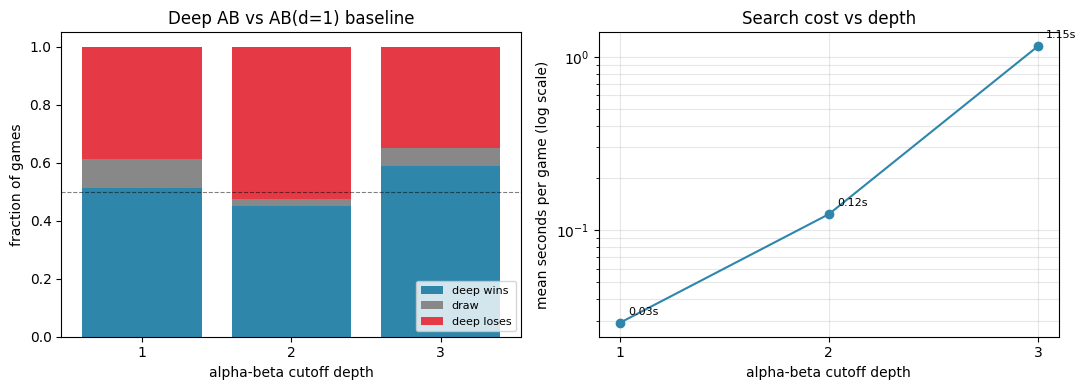

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

depths = summary_A.index.tolist()
wins = summary_A['win_deep'].values
losses = summary_A['loss_deep'].values
draws = summary_A['draw'].values
axes[0].bar(depths, wins, label='deep wins', color='#2E86AB')
axes[0].bar(depths, draws, bottom=wins, label='draw', color='#888888')
axes[0].bar(depths, losses, bottom=wins + draws, label='deep loses', color='#E63946')
axes[0].axhline(0.5, color='black', lw=0.8, ls='--', alpha=0.5)
axes[0].set_xticks(depths)
axes[0].set_xlabel('alpha-beta cutoff depth')
axes[0].set_ylabel('fraction of games')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Deep AB vs AB(d=1) baseline')
axes[0].legend(loc='lower right', fontsize=8)

axes[1].plot(depths, summary_A['mean_seconds'].values, 'o-', color='#2E86AB')
axes[1].set_yscale('log')
axes[1].set_xticks(depths)
axes[1].set_xlabel('alpha-beta cutoff depth')
axes[1].set_ylabel('mean seconds per game (log scale)')
axes[1].set_title('Search cost vs depth')
axes[1].grid(True, which='both', alpha=0.3)
for d, s in zip(depths, summary_A['mean_seconds'].values):
    axes[1].annotate(f'{s:.2f}s', (d, s), textcoords='offset points',
                     xytext=(6, 6), fontsize=8)

fig.tight_layout()
out = settings.FIGURES_DIR / 'expA_depth.png'
fig.savefig(out, dpi=120)
print('saved', out)
plt.show()


### Strength vs cost in one panel

The two-panel plot above splits W/L/D and time across separate axes. For the
report it is also useful to see them together: deeper search buys more wins
but the cost grows roughly an order of magnitude per ply, and that tradeoff
is what bounds `DEFAULT_DEPTH`. A second y-axis on a log scale makes both
trends legible at once.


saved C:\Git\AI801Project\cache\figures\expA_pareto.png


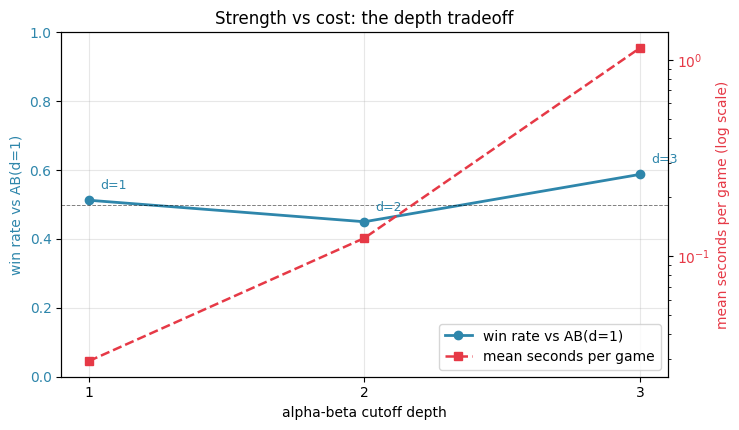

In [6]:
import matplotlib.pyplot as plt

fig, ax_left = plt.subplots(figsize=(7.5, 4.4))

depths = summary_A.index.tolist()
wr     = summary_A['win_deep'].values
secs   = summary_A['mean_seconds'].values

l1 = ax_left.plot(depths, wr, 'o-', color='#2E86AB', lw=2,
                  label='win rate vs AB(d=1)')
ax_left.axhline(0.5, color='black', ls='--', lw=0.7, alpha=0.5)
ax_left.set_xlabel('alpha-beta cutoff depth')
ax_left.set_ylabel('win rate vs AB(d=1)', color='#2E86AB')
ax_left.set_xticks(depths)
ax_left.set_ylim(0.0, 1.0)
ax_left.tick_params(axis='y', labelcolor='#2E86AB')

ax_right = ax_left.twinx()
l2 = ax_right.plot(depths, secs, 's--', color='#E63946', lw=1.8,
                   label='mean seconds per game')
ax_right.set_yscale('log')
ax_right.set_ylabel('mean seconds per game (log scale)', color='#E63946')
ax_right.tick_params(axis='y', labelcolor='#E63946')

# Annotate each point with its depth so the tradeoff is unambiguous.
for d, w, s in zip(depths, wr, secs):
    ax_left.annotate(f'd={d}', (d, w),
                     textcoords='offset points', xytext=(8, 8),
                     fontsize=9, color='#2E86AB')

lines  = l1 + l2
labels = [ln.get_label() for ln in lines]
ax_left.legend(lines, labels, loc='lower right')
ax_left.set_title('Strength vs cost: the depth tradeoff')
ax_left.grid(True, alpha=0.3)

fig.tight_layout()
out = settings.FIGURES_DIR / 'expA_pareto.png'
fig.savefig(out, dpi=120)
print('saved', out)
plt.show()


## Experiment B: pre-allocation sweep

How does the number of randomly placed initial markers affect the
outcome distribution? AB(d=DEFAULT) plays itself with sides alternated;
the proposal predicted that more pre-allocation should mean fewer ties
and shorter games.


In [7]:
def expB():
    ab = _spec("ab", depth=settings.DEFAULT_DEPTH)
    jobs = []
    for n in settings.PREALLOC_CHOICES:
        jobs.extend(make_balanced_jobs(
            ab, ab, n_prealloc=n,
            n_games=settings.N_GAMES_PER_CONFIG,
            seed=200 + n, tag=n))
    # play_one_game already records n_prealloc in each result, so we just
    # drop the redundant tag column here rather than renaming over it.
    return games_to_df(run_games(jobs), label_a="AB", label_b="AB").drop(columns="tag")

dfB = run_or_load("expB_prealloc_sweep", expB)

# AB plays itself with sides alternated, so the X/O split is meaningless --
# what matters is how often games end decisively and how long they take.
summary_B = (dfB.groupby("n_prealloc")
                 .agg(decisiveness=("winner", lambda s: (s != "draw").mean()),
                      draw_rate   =("winner", lambda s: (s == "draw").mean()),
                      mean_plies  =("plies",  "mean"),
                      median_plies=("plies",  "median")))
summary_B

[run]   computing expB_prealloc_sweep.pkl ...


        done in 20.2s


,decisiveness,draw_rate,mean_plies,median_plies
n_prealloc,,,,
1,0.9125,0.0875,17.9875,17.0
2,0.8125,0.1875,16.9000,15.0
3,0.9375,0.0625,14.1000,13.0


### Visualizing the pre-allocation sweep

Mean game length per pre-allocation setting with 95% confidence
intervals on the mean (standard normal approximation), with the draw
rate alongside. More pre-placed markers leaves less of the board to
fill, so games end faster. The bars on the right confirm the trend.

The draw rates are point estimates from `N_GAMES_PER_CONFIG=80` games
per setting. Their Wilson 95% intervals (printed by the cell) overlap
heavily, so any small non-monotonicity (n=2 sitting above n=1 and n=3,
for instance) is consistent with sampling noise rather than a real
effect.


saved C:\Git\AI801Project\cache\figures\expB_prealloc.png


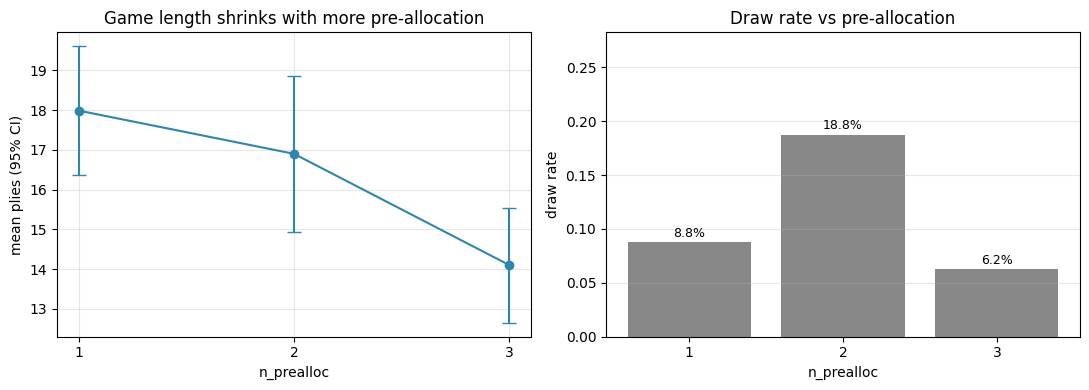

draw rate Wilson 95% CI per n_prealloc:
  n=1: rate 0.087  CI [0.043, 0.170]  (N=80)
  n=2: rate 0.188  CI [0.117, 0.287]  (N=80)
  n=3: rate 0.062  CI [0.027, 0.138]  (N=80)


In [8]:
import matplotlib.pyplot as plt

stats = (dfB.groupby('n_prealloc')['plies']
             .agg(['mean', 'std', 'count']))
stats['se'] = stats['std'] / stats['count'].pow(0.5)
stats['ci95'] = 1.96 * stats['se']

draws = (dfB.groupby('n_prealloc')['winner']
             .apply(lambda s: (s == 'draw').mean()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(stats.index, stats['mean'], yerr=stats['ci95'],
                 fmt='o-', capsize=5, color='#2E86AB')
axes[0].set_xticks(stats.index)
axes[0].set_xlabel('n_prealloc')
axes[0].set_ylabel('mean plies (95% CI)')
axes[0].set_title('Game length shrinks with more pre-allocation')
axes[0].grid(True, alpha=0.3)

axes[1].bar(draws.index, draws.values, color='#888888')
for x, y in zip(draws.index, draws.values):
    axes[1].text(x, y + 0.005, f'{y:.1%}', ha='center', fontsize=9)
axes[1].set_xticks(draws.index)
axes[1].set_xlabel('n_prealloc')
axes[1].set_ylabel('draw rate')
axes[1].set_ylim(0, max(draws.values) * 1.4 + 0.02)
axes[1].set_title('Draw rate vs pre-allocation')
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
out = settings.FIGURES_DIR / 'expB_prealloc.png'
fig.savefig(out, dpi=120)
print('saved', out)
plt.show()

# Report Wilson 95% CIs alongside the point estimates so the (small)
# non-monotonicity in the draw rate is read as noise, not signal.
from math import sqrt
def _wilson_ci(p, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    den = 1 + z * z / n
    center = (p + z * z / (2 * n)) / den
    half = z * sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (center - half, center + half)

n_per_setting = dfB.groupby('n_prealloc').size()
print('draw rate Wilson 95% CI per n_prealloc:')
for k, p in draws.items():
    lo, hi = _wilson_ci(p, int(n_per_setting.loc[k]))
    print(f'  n={k}: rate {p:.3f}  CI [{lo:.3f}, {hi:.3f}]  (N={int(n_per_setting.loc[k])})')


### Game-length distributions per pre-allocation

Mean ± CI is a fine summary but it hides the spread. Boxplots show the
full distribution of game lengths per `n_prealloc`: the median, the
inter-quartile range, and how long the longest games actually got. This
is the more honest version of the bar plot above, and is the one I would
put in the report.


saved C:\Git\AI801Project\cache\figures\expB_boxplot.png


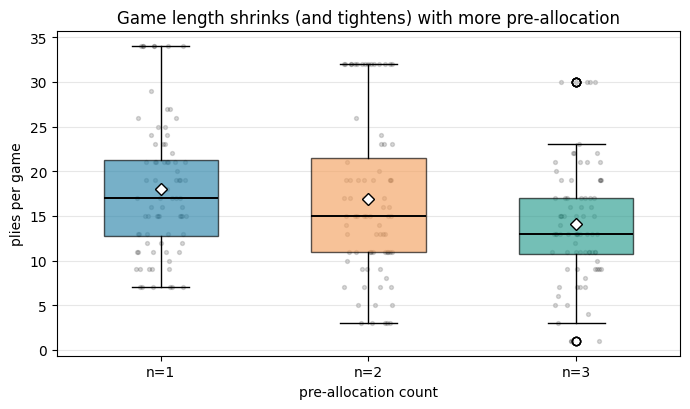

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.0, 4.2))

groups = sorted(dfB['n_prealloc'].unique())
data   = [dfB.loc[dfB['n_prealloc'] == g, 'plies'].values for g in groups]
bp = ax.boxplot(data, tick_labels=[f'n={g}' for g in groups],
                showmeans=True, patch_artist=True, widths=0.55,
                medianprops=dict(color='black', linewidth=1.4),
                meanprops=dict(marker='D', markerfacecolor='white',
                               markeredgecolor='black', markersize=6))
palette = ['#2E86AB', '#F4A261', '#2A9D8F']
for patch, c in zip(bp['boxes'], palette):
    patch.set_facecolor(c)
    patch.set_alpha(0.65)

# Overlay individual game points (jittered) so it is clear how many games
# we are summarizing per box.
import numpy as np
rng = np.random.default_rng(0)
for i, vals in enumerate(data, start=1):
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(np.full_like(vals, i, dtype=float) + jitter, vals,
               s=8, color='black', alpha=0.15)

ax.set_ylabel('plies per game')
ax.set_xlabel('pre-allocation count')
ax.set_title('Game length shrinks (and tightens) with more pre-allocation')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
out = settings.FIGURES_DIR / 'expB_boxplot.png'
fig.savefig(out, dpi=120)
print('saved', out)
plt.show()


## Experiment C: heuristic-weight tuning

A small grid around the default weights, varying the three knobs that
matter most (`w_three`, `w_block_three`, `w_center`), with each
candidate playing the default-weighted opponent at `TUNING_DEPTH`. A
`default vs default` control row is included so the baseline win rate
should land near 0.5. If it doesn't, the comparison is biased and the
rest of the table is suspect.

All games (one control + 18 grid + `N_RANDOM_CANDIDATES` random) go
into a single pool batch so the slow candidates don't stall behind the
fast ones.

The grid keeps the heatmap visualization tidy and lets us reason about
each axis in isolation. The random samples cover the gaps the grid
leaves and give the optimizer a chance to find a setting no row in the
grid would have proposed.


> **Note on opponent panel.** This expC screen plays every candidate
> against a single opponent (the default-weighted agent). That keeps the
> tuning fast and matches the original setup, but a candidate that wins
> here may simply be exploiting one specific opponent's weights.
> Notebook 04 re-runs this with two opponents and ranks by the worse of
> the two so the comparison is broader; the result still has to clear
> the validation step before any weights are shipped.


In [10]:
def expC():
    base     = settings.DEFAULT_HEURISTIC_WEIGHTS
    opp_spec = make_spec("ab", depth=settings.TUNING_DEPTH)
    n        = settings.N_TUNING_GAMES

    # Build a single (tag, weights, is_control) list covering every config.
    # Control = default vs default (sanity ~50%); grid = 3x3x2 around base;
    # random = N_RANDOM_CANDIDATES samples (Bergstra & Bengio 2012).
    configs = [("control", dict(base), True)]

    grid = itertools.product(
        [base["w_three"]       * 0.5, base["w_three"],       base["w_three"]       * 2.0],
        [base["w_block_three"] * 0.5, base["w_block_three"], base["w_block_three"] * 2.0],
        [0.0,                          base["w_center"]       * 4.0],
    )
    for idx, (w3, wb3, wc) in enumerate(grid):
        configs.append((f"cand_{idx:02d}",
                        dict(base, w_three=w3, w_block_three=wb3, w_center=wc),
                        False))

    rng = random.Random(7777)
    for ridx in range(settings.N_RANDOM_CANDIDATES):
        configs.append((f"rand_{ridx:02d}",
                        dict(base,
                             w_three      =rng.uniform(2.0, 30.0),
                             w_block_three=rng.uniform(2.0, 20.0),
                             w_center     =rng.uniform(0.0,  3.0)),
                        False))

    # One flat batch -> shared ProcessPool keeps every core busy regardless
    # of which configs happen to produce slow games.
    jobs = []
    for seed_idx, (tag, weights, is_control) in enumerate(configs):
        spec_a = opp_spec if is_control else make_spec(
            "ab", depth=settings.TUNING_DEPTH, weights=weights)
        jobs.extend(make_balanced_jobs(
            spec_a, opp_spec, 2, n, seed=300 + seed_idx, tag=tag))

    print(f"  expC submitting {len(jobs)} games to {MAX_WORKERS} workers ...")
    df_all = games_to_df(run_games(jobs), label_a="cand", label_b="base")

    rows = []
    for tag, weights, is_control in configs:
        sub = df_all[df_all["tag"] == tag]
        rows.append(dict(
            tag=tag, control=is_control,
            w_three      =weights["w_three"],
            w_block_three=weights["w_block_three"],
            w_center     =weights["w_center"],
            win_rate =(sub["winner_label"] == "cand").mean(),
            loss_rate=(sub["winner_label"] == "base").mean(),
            draw_rate=(sub["winner_label"] == "draw").mean(),
            mean_plies=sub["plies"].mean(),
        ))
    return pd.DataFrame(rows)

dfC = run_or_load("expC_weight_tuning", expC)
dfC.sort_values("win_rate", ascending=False)

[run]   computing expC_weight_tuning.pkl ...
  expC submitting 3120 games to 32 workers ...


        done in 24.1s


,tag,control,w_three,w_block_three,w_center,win_rate,loss_rate,draw_rate,mean_plies
11,cand_10,False,10.000000,16.000000,0.000000,0.6750,0.3250,0.0000,13.2250
5,cand_04,False,5.000000,16.000000,0.000000,0.6500,0.3500,0.0000,12.6250
12,cand_11,False,10.000000,16.000000,2.000000,0.6375,0.3625,0.0000,13.5625
33,rand_14,False,20.360957,16.309054,0.821251,0.6125,0.3875,0.0000,12.1375
32,rand_13,False,28.832824,19.062791,2.257963,0.6125,0.3875,0.0000,11.7875
6,cand_05,False,5.000000,16.000000,2.000000,0.6125,0.3875,0.0000,13.4875
4,cand_03,False,5.000000,8.000000,2.000000,0.6000,0.4000,0.0000,14.3750
20,rand_01,False,3.858891,9.591733,1.674418,0.6000,0.4000,0.0000,14.0500
30,rand_11,False,5.264417,17.714470,2.643272,0.6000,0.4000,0.0000,12.8000
3,cand_02,False,5.000000,8.000000,0.000000,0.6000,0.4000,0.0000,13.0500


### Visualizing the weight grid

The full grid as a heatmap (one panel per `w_center` value), with the
candidates sorted by win rate alongside. Dashed horizontal lines mark
the 50% control band and the 55% selection threshold, so it's easy to
see how many candidates clear the bar set in the validation step.

The ranking bar carries Wilson 95% intervals on each candidate's win
rate. At `N_GAMES_PER_CONFIG=80` those intervals are wide (about
+/-0.11), and that overlap is the main reason we re-validate the top
picks at the deployment depth in the next section before committing to
any tuned weights.


saved C:\Git\AI801Project\cache\figures\expC_weights.png


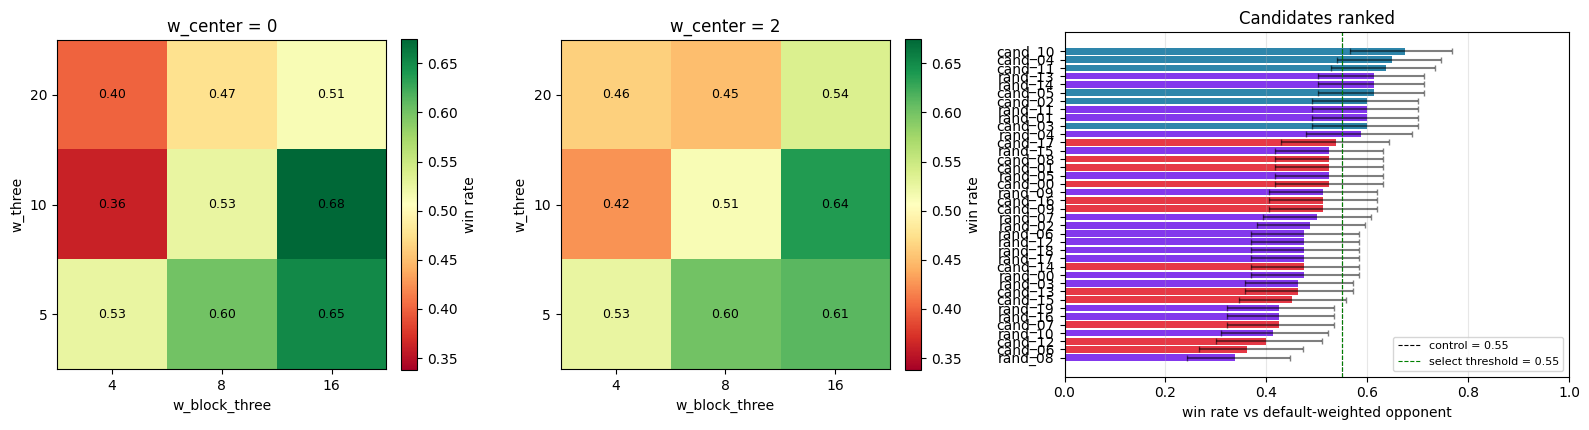

In [11]:
import matplotlib.pyplot as plt
import numpy as np

cand = dfC[~dfC['control']].copy()
cand['is_random'] = cand['tag'].str.startswith('rand_')
ctrl_winrate = float(dfC[dfC['control']].iloc[0]['win_rate'])

centers = sorted(cand[~cand['is_random']]['w_center'].unique())
threes  = sorted(cand[~cand['is_random']]['w_three'].unique())
blocks  = sorted(cand[~cand['is_random']]['w_block_three'].unique())

fig, axes = plt.subplots(1, len(centers) + 1, figsize=(5 * len(centers) + 6, 4.4),
                          gridspec_kw={'width_ratios': [1] * len(centers) + [1.4]})

vmin = cand['win_rate'].min()
vmax = cand['win_rate'].max()
grid_only = cand[~cand['is_random']]
for ax, wc in zip(axes[:len(centers)], centers):
    sub = grid_only[grid_only['w_center'] == wc]
    grid = np.full((len(threes), len(blocks)), np.nan)
    for _, row in sub.iterrows():
        i = threes.index(row['w_three'])
        j = blocks.index(row['w_block_three'])
        grid[i, j] = row['win_rate']
    im = ax.imshow(grid, cmap='RdYlGn', vmin=vmin, vmax=vmax,
                   origin='lower')
    ax.set_xticks(range(len(blocks)))
    ax.set_xticklabels([f'{b:g}' for b in blocks])
    ax.set_yticks(range(len(threes)))
    ax.set_yticklabels([f'{t:g}' for t in threes])
    ax.set_xlabel('w_block_three')
    ax.set_ylabel('w_three')
    ax.set_title(f'w_center = {wc:g}')
    for i in range(len(threes)):
        for j in range(len(blocks)):
            v = grid[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='win rate')

# wilson_ci_expC: confidence intervals on each candidate's win rate
from math import sqrt as _sqrt
def _wilson_ci_expC(p, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    den = 1 + z * z / n
    center = (p + z * z / (2 * n)) / den
    half = z * _sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (center - half, center + half)
N_per_cand = int(settings.N_TUNING_GAMES)
cand_ci = cand.assign(
    _ci=cand['win_rate'].apply(lambda p: _wilson_ci_expC(p, N_per_cand)))
cand_ci['_lo'] = cand_ci['_ci'].apply(lambda t: t[0])
cand_ci['_hi'] = cand_ci['_ci'].apply(lambda t: t[1])

ranked = cand_ci.sort_values('win_rate', ascending=True)
ax = axes[-1]
xerr_lo = (ranked['win_rate'] - ranked['_lo']).clip(lower=0)
xerr_hi = (ranked['_hi'] - ranked['win_rate']).clip(lower=0)
bars = ax.barh(ranked['tag'], ranked['win_rate'],
               xerr=[xerr_lo, xerr_hi],
               error_kw=dict(ecolor='black', alpha=0.5, capsize=2),
               color=['#8338EC' if r else ('#2E86AB' if v >= 0.55 else '#E63946' if v < ctrl_winrate else '#888888')
                      for v, r in zip(ranked['win_rate'], ranked['is_random'])])
ax.axvline(ctrl_winrate, color='black', ls='--', lw=0.8,
           label=f'control = {ctrl_winrate:.2f}')
ax.axvline(0.55, color='green', ls='--', lw=0.8, label='select threshold = 0.55')
ax.set_xlabel('win rate vs default-weighted opponent')
ax.set_xlim(0, 1)
ax.set_title('Candidates ranked')
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.3)

fig.tight_layout()
out = settings.FIGURES_DIR / 'expC_weights.png'
fig.savefig(out, dpi=120)
print('saved', out)
plt.show()


### Validation at the deployment depth

Tuning at `TUNING_DEPTH` is cheap, but the winner there isn't
guaranteed to still be the winner at `DEFAULT_DEPTH`. So we re-play the
top-K candidates at the deeper depth before committing to a set of
weights. If none of them convincingly beats the baseline (>= 55%
win rate), the cell falls back to the defaults.

This step is also our guard against overfitting to the tuning set.
Tuning may not transfer when the tuning- and deployment-depth searches
resolve threats differently, or when the tuning sample size is too
small to separate the top candidates from the control. In either case
the cell below silently falls back to the default weights so the rest
of the pipeline still runs.


In [12]:
# expC was a *screen*: 38 candidates ranked by a noisy d=2 win rate.
# Picking the apparent top-3 from a noisy distribution is classic
# selection bias, so the validation step here:
#   (a) re-plays a wider top-K at DEFAULT_DEPTH with fresh seeds, and
#   (b) requires each candidate to clear a Bonferroni-aware threshold,
#       not just 0.55.
candidates = dfC[~dfC["control"]].sort_values("win_rate", ascending=False)
ctrl_winrate = float(dfC[dfC["control"]].iloc[0]["win_rate"])
print(f"Control (default vs default) win-rate: {ctrl_winrate:.3f}  "
      f"(should be ~0.5; large deviations indicate a biased comparison)")

TOP_K        = 6
default_spec = make_spec("ab", depth=settings.DEFAULT_DEPTH)
top          = candidates.head(TOP_K).reset_index(drop=True)

# Build all validation jobs up front so the pool stays saturated.
jobs            = []
weights_by_tag  = {}
for i, row in top.iterrows():
    weights = dict(settings.DEFAULT_HEURISTIC_WEIGHTS,
                   w_three      =float(row["w_three"]),
                   w_block_three=float(row["w_block_three"]),
                   w_center     =float(row["w_center"]))
    tag = f"val_{i}"
    weights_by_tag[tag] = weights
    cand_spec = make_spec("ab", depth=settings.DEFAULT_DEPTH, weights=weights)
    # seed=400+i is disjoint from all expC tuning seeds (300..399, 900..919),
    # so validation is on a fresh, non-overlapping game stream.
    jobs.extend(make_balanced_jobs(cand_spec, default_spec, 2,
                                   settings.N_GAMES_PER_CONFIG,
                                   seed=400 + i, tag=tag))

print(f"  validation submitting {len(jobs)} games ...")
df_v = games_to_df(run_games(jobs), label_a="cand", label_b="base")

# Bonferroni-style threshold: testing TOP_K candidates against the null
# p=0.5 at alpha=0.05 family-wise, one-sided. With N=N_GAMES_PER_CONFIG
# the per-test SE at p=0.5 is sqrt(0.25/N).
from math import sqrt as _sqrt
from scipy.stats import norm as _norm
_alpha = 0.05 / TOP_K
_z     = _norm.ppf(1 - _alpha)
_se    = _sqrt(0.25 / settings.N_GAMES_PER_CONFIG)
THRESHOLD = round(0.5 + _z * _se, 3)
print(f"  Bonferroni threshold for K={TOP_K} at alpha=0.05: "
      f"win-rate >= {THRESHOLD}")

validation = []
for i, row in top.iterrows():
    tag = f"val_{i}"
    sub = df_v[df_v["tag"] == tag]
    validation.append(dict(
        weights      =weights_by_tag[tag],
        tune_winrate =float(row["win_rate"]),
        d3_winrate   =(sub["winner_label"] == "cand").mean(),
        d3_lossrate  =(sub["winner_label"] == "base").mean(),
        d3_drawrate  =(sub["winner_label"] == "draw").mean()))
val_df = pd.DataFrame(validation)
print(val_df[["tune_winrate", "d3_winrate", "d3_lossrate", "d3_drawrate"]])

best_row = val_df.iloc[val_df["d3_winrate"].idxmax()]
if best_row["d3_winrate"] >= THRESHOLD:
    best_weights = best_row["weights"]
    print(f"Selected tuned weights (d=3 win-rate {float(best_row['d3_winrate']):.3f} "
          f">= threshold {THRESHOLD}). Treat tuned weights as exploratory: "
          f"this clears family-wise alpha but is not a confirmatory result.")
else:
    best_weights = dict(settings.DEFAULT_HEURISTIC_WEIGHTS)
    print(f"No tuned candidate cleared the Bonferroni threshold "
          f"({THRESHOLD}); keeping default weights.")

settings.cache_path("best_weights.pkl").write_bytes(pickle.dumps(best_weights))
print("best weights saved to", settings.cache_path("best_weights.pkl"))
best_weights


Control (default vs default) win-rate: 0.550  (should be ~0.5; large deviations indicate a biased comparison)
  validation submitting 480 games ...


  Bonferroni threshold for K=6 at alpha=0.05: win-rate >= 0.634
   tune_winrate  d3_winrate  d3_lossrate  d3_drawrate
0        0.6750      0.3500       0.4625       0.1875
1        0.6500      0.3375       0.5375       0.1250
2        0.6375      0.3375       0.5375       0.1250
3        0.6125      0.4375       0.4875       0.0750
4        0.6125      0.5250       0.4125       0.0625
5        0.6125      0.3250       0.5000       0.1750
No tuned candidate cleared the Bonferroni threshold (0.634); keeping default weights.
best weights saved to C:\Git\AI801Project\cache\results\best_weights.pkl


{'w_two': 1.0,
 'w_three': 10.0,
 'w_block_two': 1.0,
 'w_block_three': 8.0,
 'w_open_three': 0.0,
 'w_block_open_three': 0.0,
 'w_center': 0.5,
 'w_win': 10000.0}